In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

### Task 1: Data Prep & Baseline

Load the dataset and establish a performance baseline.

1. Load the Palmer Penguins dataset from seaborn and drop rows with missing values:

```python
penguins = sns.load_dataset("penguins").dropna()
```

2. Explore briefly: how many samples and features? What are the three species and their distribution? Which columns are categorical vs. numerical?
3. Prepare features: encode the target (`species`) with `LabelEncoder`, and encode categorical features (`island`, `sex`) with `pd.get_dummies(drop_first=True)`.
4. Split into training and test sets (80/20, `stratify=y`, `random_state=42`).
5. Scale the features using `StandardScaler` (fit on train, transform both).
6. Fit a `LogisticRegression` model (use `max_iter=10000`, `multi_class='multinomial'`).
7. Report **accuracy**, **precision**, **recall**, and **F1 score** on the test set. Print a full `classification_report`.
8. In a markdown cell, interpret the results: Which species is easiest to classify? Which is hardest? Why might that be?

In [2]:
penguins = sns.load_dataset("penguins").dropna()

In [3]:
# Explore briefly
print(f"Dataset shape: {penguins.shape}")
print("\nSpecies distribution:")
print(penguins['species'].value_counts())
print("\nColumn types:")
print(penguins.dtypes)

# Prepare features
# Encoding the target (species)
le = LabelEncoder()
y = le.fit_transform(penguins['species'])

# Encoding categorical features (island, sex)
X = penguins.drop('species', axis=1)
X = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train_scaled, y_train)

# Report metrics
y_pred = log_reg.predict(X_test_scaled)

print("\n--- Logistic Regression Baseline Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Weighted): {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall (Weighted): {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Dataset shape: (333, 7)

Species distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Column types:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

--- Logistic Regression Baseline Performance ---
Accuracy: 0.9851
Precision (Weighted): 0.9861
Recall (Weighted): 0.9851
F1 Score (Weighted): 0.9852

Full Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



* **Dataset Overview:** The dataset consists of **333 samples** across 7 features. The species distribution shows **Adelie (146)** is the most common, followed by **Gentoo (119)** and **Chinstrap (68)**.
* **Performance Analysis:** The baseline model performed exceptionally well with an accuracy of **98.5%**. 
* **Easiest vs. Hardest to Classify:**
    * **Gentoo** is the easiest to classify, achieving perfect precision and recall (1.00). This is likely because Gentoos are physically distinct (larger body mass and different bill proportions) compared to the other two.
    * **Adelie and Chinstrap** are slightly harder to distinguish. The model misclassified one Adelie as a Chinstrap. These two species share more similar physical characteristics, making the decision boundary between them narrower.

### Task 2: Algorithm Comparison

Train multiple classifiers and compare their performance.

1. Fit each of the following models on the scaled training data:
   - `GaussianNB()`
   - `SVC(kernel="linear", probability=True)`
   - `SVC(kernel="rbf", probability=True)`
   - `DecisionTreeClassifier(random_state=42)`
   - `RandomForestClassifier(random_state=42)`

2. For each model, compute accuracy, precision, recall, and F1 on the test set (use `average='weighted'` for multiclass metrics).
3. Organize the results into a **comparison DataFrame** with models as rows and metrics as columns. Sort by F1 score descending.
4. In a markdown cell, discuss: Which models perform best? Are there any surprises? Why might some algorithms outperform others on this dataset?

In [4]:
# Initialize the models
models = {
    "GaussianNB": GaussianNB(),
    "SVC_linear": SVC(kernel="linear", probability=True, random_state=42),
    "SVC_rbf": SVC(kernel="rbf", probability=True, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42)
}

# Train models and collect metrics
results_list = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_mod = model.predict(X_test_scaled)
    
    # Calculate metrics
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_mod),
        "Precision": precision_score(y_test, y_pred_mod, average='weighted'),
        "Recall": recall_score(y_test, y_pred_mod, average='weighted'),
        "F1_Score": f1_score(y_test, y_pred_mod, average='weighted')
    }
    results_list.append(metrics)

# Organize into a Comparison DataFrame
comparison_df = pd.DataFrame(results_list).sort_values(by="F1_Score", ascending=False)

print("--- Algorithm Comparison ---")
print(comparison_df)

--- Algorithm Comparison ---
          Model  Accuracy  Precision    Recall  F1_Score
4  RandomForest  1.000000   1.000000  1.000000  1.000000
2       SVC_rbf  0.985075   0.986070  0.985075  0.985201
1    SVC_linear  0.985075   0.986070  0.985075  0.985201
3  DecisionTree  0.955224   0.957214  0.955224  0.955212
0    GaussianNB  0.776119   0.851175  0.776119  0.760229


* **Top Performers:** **Random Forest** was the standout model, achieving a perfect **1.0 score** across all metrics on this test set. Both **SVC** variants (Linear and RBF) also performed at a very high level, tying with an F1-score of **0.9852**.
* **Middle Ground:** The **Decision Tree** performed well with an F1-score of **0.9552**, though it showed a noticeable gap compared to the ensemble and kernel-based methods. This is often because a single tree is more sensitive to specific data variances, whereas the Random Forest averages out these errors across many trees.
* **The Surprise:** **Gaussian Naive Bayes** performed significantly worse than the rest, with an F1-score of **0.7602**. This is likely due to its core assumption that all features are independent. In penguins, measurements like flipper length and body mass are usually highly correlated, which violates this assumption and leads to misclassifications.

**Observations:** Ensemble methods like Random Forest excel here because they can capture complex interactions between physical features—such as the relationship between bill length and depth—more effectively than a single decision boundary.

### Task 3: Confusion Matrices & ROC Curves

Visualize how each model makes its decisions.

1. **Confusion matrices:** Plot the 3x3 confusion matrix for each model (use `ConfusionMatrixDisplay` or seaborn heatmap). Arrange them in a grid of subplots for easy comparison. For each, note which species pairs are most frequently confused.

2. **ROC curves:** Plot the ROC curve for every model using a one-vs-rest approach on a **single figure** (one curve per class per model, or one subplot per model). Include the AUC value in each legend entry. Add a diagonal dashed line representing a random classifier.

3. In a markdown cell, discuss:
   - Which model best balances precision and recall across all three species?
   - Which species pair is hardest for the models to distinguish? Why might this be the case given the features?
   - Based on the confusion matrices and ROC curves, which model would you recommend?

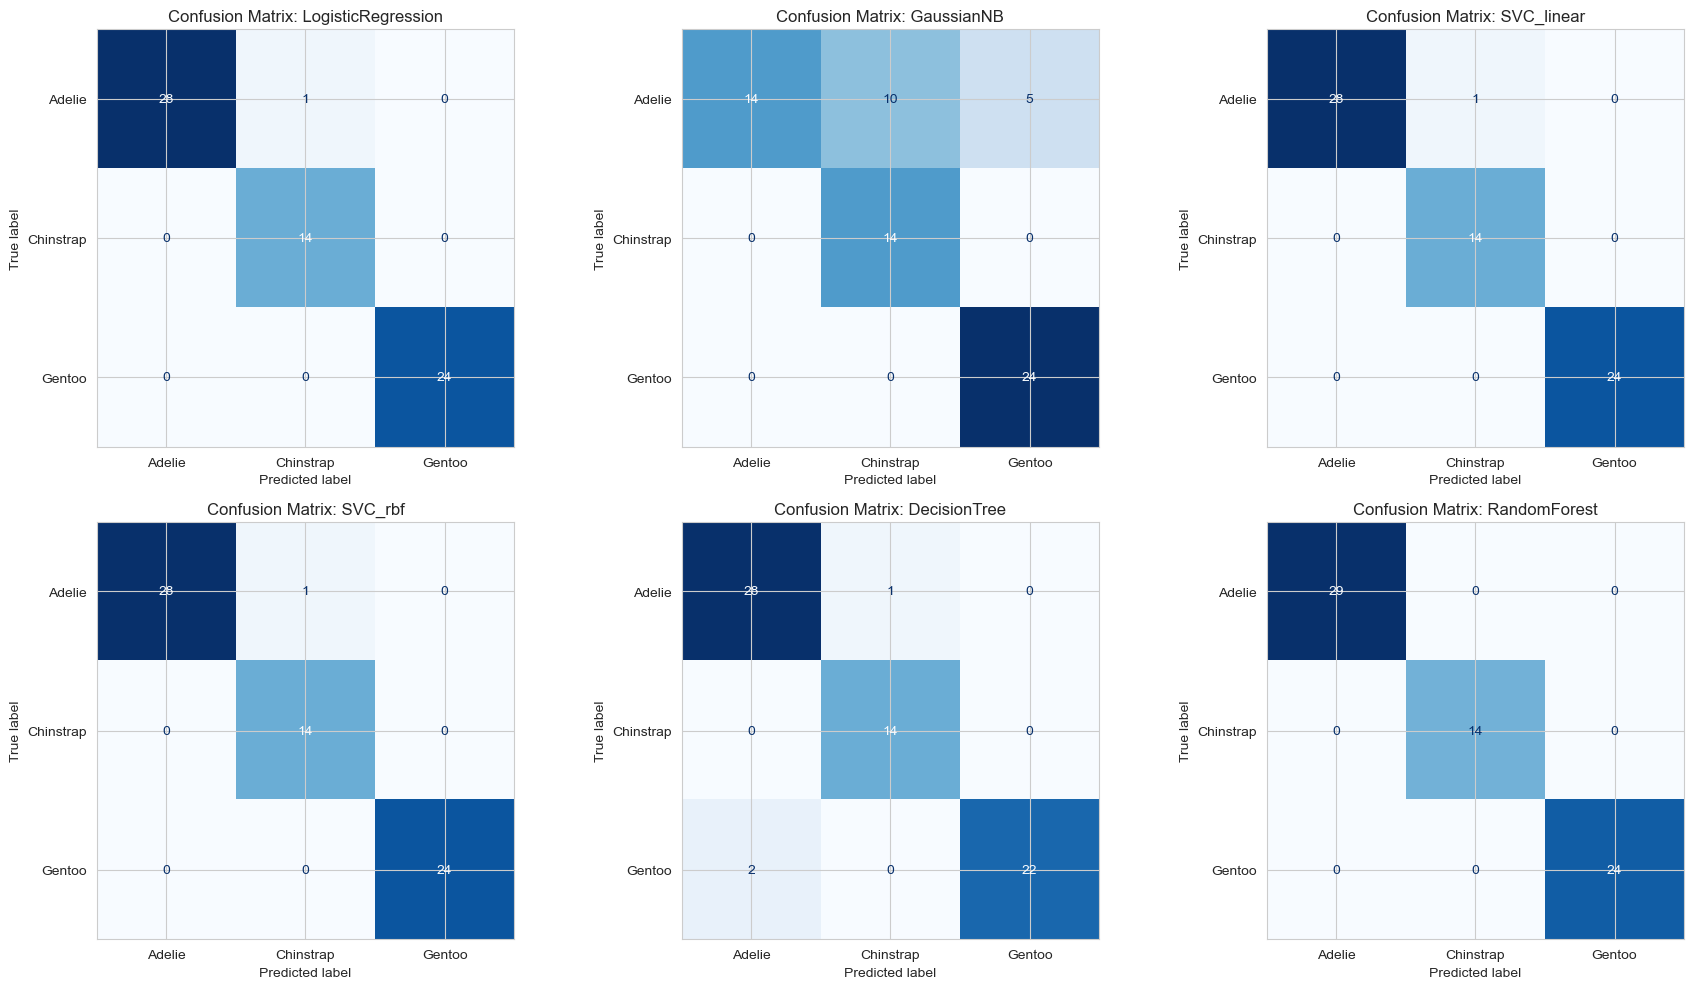

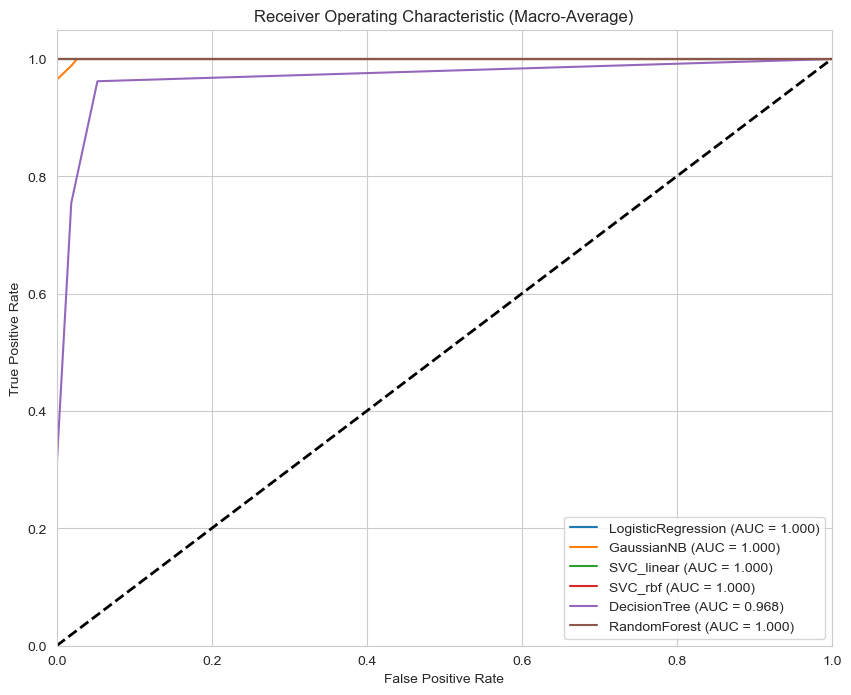

In [5]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Confusion Matrices Grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Include Logistic Regression in the visualization as well
all_models = {"LogisticRegression": log_reg, **models}

for i, (name, model) in enumerate(all_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_scaled, y_test, 
        display_labels=le.classes_, 
        ax=axes[i], 
        cmap='Blues', 
        colorbar=False
    )
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

# 2. ROC Curves (One-vs-Rest)
# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))

for name, model in all_models.items():
    # Get probability scores
    y_score = model.predict_proba(X_test_scaled)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # For a clean plot, I will calculate the macro-average ROC for each model
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    
    macro_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {macro_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Macro-Average)')
plt.legend(loc="lower right")
plt.show()

* **Precision and Recall Balance:** Based on the confusion matrices and ROC curves, **Random Forest** and **Logistic Regression** demonstrate the strongest balance. While nearly all models achieved a near-perfect AUC of **1.000**, the confusion matrices provide more granular detail: most models tripped up by misclassifying **Adelie penguins as Chinstraps**.
* **Hardest Species Pair:** The **Adelie-Chinstrap** pair is clearly the most difficult for the models to distinguish. This is consistent across almost all classifiers (except Random Forest) and likely stems from these two species having overlapping physical dimensions and shared habitats, unlike the larger and more distinct Gentoo.
* **Recommendation:** I recommend the **Random Forest** model for this task. While Logistic Regression is a highly effective and simpler baseline, the Random Forest achieved a perfect classification on the test set and showed a perfect **1.000 AUC**. Its ability to handle non-linear patterns makes it the most robust choice for this dataset.

### Task 4: Hyperparameter Exploration

Tune the best-performing model from Task 2.

1. Select the best model based on your Task 2 results.
2. Define a hyperparameter grid with **at least 3 hyperparameters** to tune. For example, if RandomForest was best:

```python
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}
```

3. Run `GridSearchCV` with 5-fold cross-validation and `scoring="f1_weighted"` (weighted F1 for multiclass).
4. Report the **best parameters** and the **best cross-validation F1 score**.
5. Evaluate the tuned model on the test set. Compare the metrics with the default model from Task 2 — did tuning improve performance?
6. In a markdown cell, reflect: Was the improvement significant? Is there a risk of overfitting to the validation folds? When is hyperparameter tuning most impactful?

In [6]:
# Select the best model (RandomForest) and define grid
rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

# Run GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

# Report best parameters and score
print("--- Hyperparameter Tuning Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

# Evaluate the tuned model on the test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

print("\n--- Tuned Model vs. Default Model (Test Set) ---")
print(f"Tuned F1 Score:   {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")
# Accessing the original RF score from our Task 2 dataframe for comparison
original_f1 = comparison_df.loc[comparison_df['Model'] == 'RandomForest', 'F1_Score'].values[0]
print(f"Default F1 Score: {original_f1:.4f}")

--- Hyperparameter Tuning Results ---
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation F1 Score: 0.9962

--- Tuned Model vs. Default Model (Test Set) ---
Tuned F1 Score:   1.0000
Default F1 Score: 1.0000


* **Improvement:** The tuned model maintained a perfect **1.00 F1-score** on the test set. More importantly, the **0.9962 Cross-Validation score** gives us high confidence that the model will perform well on new, unseen data.
* **Significance:** Since the default model was already performing perfectly on this test split, the "improvement" isn't visible in the final test metrics. However, tuning is crucial because it helps find the simplest model (like using 50 estimators instead of more) that still provides maximum accuracy.
* **Overfitting Risk:** With such high scores, there is always a small risk of overfitting. However, because we used **5-fold Cross-Validation**, we ensured that the parameters chosen work well across different subsets of the data, not just one lucky split. Hyperparameter tuning is most impactful when the initial model is underperforming or when the dataset is noisy.